COMP3420 Artificial Intelligence for Text and Vision

In [1]:
# General
from pathlib import Path
import random
import copy

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

from pathlib import Path

# Dataset splitting
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Image handling
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# TorchVision
from torchvision import transforms, models


# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# General dataset information
image_root = Path("Images_of_Waste/rawimgs")

classes = ["AluCan", "Glass", "HDPEM", "PET"]

class_to_index = {
    "AluCan": 0,
    "Glass": 1,
    "HDPEM": 2,
    "PET": 3
}

index_to_class = {
    value: key for key, value in class_to_index.items()
}

import cv2

Device: cpu


Task 1 - Data Exploration and Preparation

1.1 Partition into training, devtest and test sets

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
dataset = pd.read_csv("waste_dataset.csv")

# Split the dataset into 60% training and 40% remaining data
train, remaining = train_test_split(
    dataset,
    test_size=0.4,
    random_state=42,
    stratify=dataset["label"]
)

# Split the remaining 40% equally into 20% devtest and 20% test
devtest, test = train_test_split(
    remaining,
    test_size=0.5,
    random_state=42,
    stratify=remaining["label"]
)

# Display dataset sizes
print("Training set shape:", train.shape)
print("Devtest set shape:", devtest.shape)
print("Test set shape:", test.shape)

# Display the class counts in each dataset
print("\nTraining class counts:")
print(train["label"].value_counts())

print("\nDevtest class counts:")
print(devtest["label"].value_counts())

print("\nTest class counts:")
print(test["label"].value_counts())

# Check that there is no overlap between the three datasets
train_paths = set(train["path"])
devtest_paths = set(devtest["path"])
test_paths = set(test["path"])

print("\nTrain/devtest overlap:",
      len(train_paths.intersection(devtest_paths)))

print("Train/test overlap:",
      len(train_paths.intersection(test_paths)))

print("Devtest/test overlap:",
      len(devtest_paths.intersection(test_paths)))

# Check that the total number of images is unchanged
print("\nTotal number of images:",
      len(train) + len(devtest) + len(test))

# Save the three datasets as CSV files
train.to_csv("train.csv", index=False)
devtest.to_csv("devtest.csv", index=False)
test.to_csv("test.csv", index=False)

Training set shape: (1860, 2)
Devtest set shape: (620, 2)
Test set shape: (620, 2)

Training class counts:
label
Glass     600
AluCan    600
PET       600
HDPEM      60
Name: count, dtype: int64

Devtest class counts:
label
PET       200
AluCan    200
Glass     200
HDPEM      20
Name: count, dtype: int64

Test class counts:
label
AluCan    200
Glass     200
PET       200
HDPEM      20
Name: count, dtype: int64

Train/devtest overlap: 0
Train/test overlap: 0
Devtest/test overlap: 0

Total number of images: 3100


The dataset was divided randomly into a 60% and 40% set. Afterwards, the 40% set was split in half to make devtest and test sets. A fixed "random_state" was used in order to allow reproduction of the test every time the notebook is run. Stratified splitting was done through the usage of class labels so each dataset kept the approximately same proportion of AluCan, Glass, PET and HDPEM images as the original dataset. This meant that the original class imbalance was kept instead of being removed, as required.

1.2 Dataset Exploration

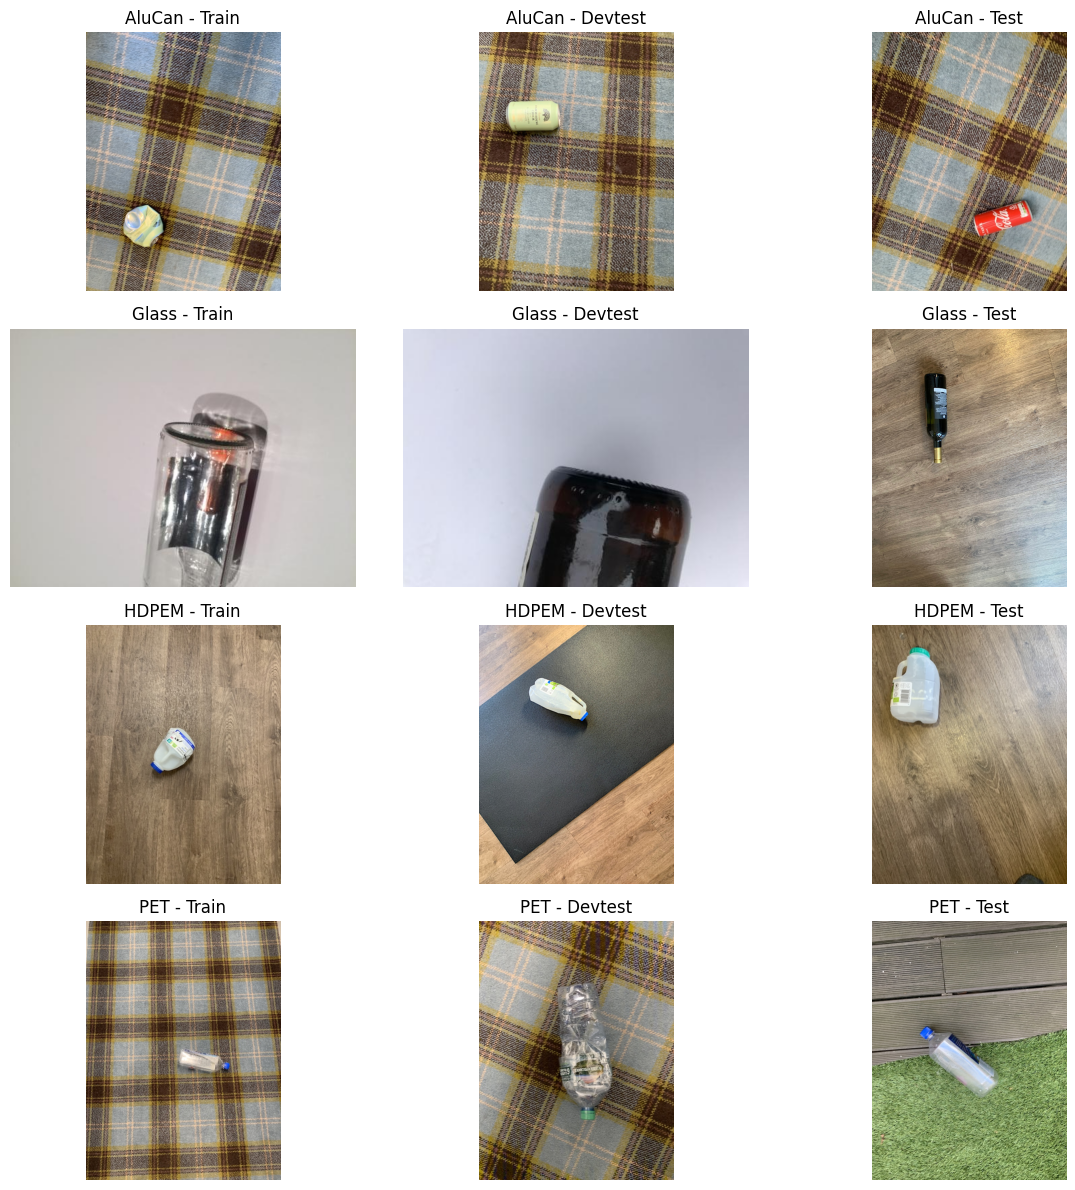


Train class counts:
label
AluCan    600
Glass     600
HDPEM      60
PET       600
Name: count, dtype: int64
Imbalance ratio: 10.0:1


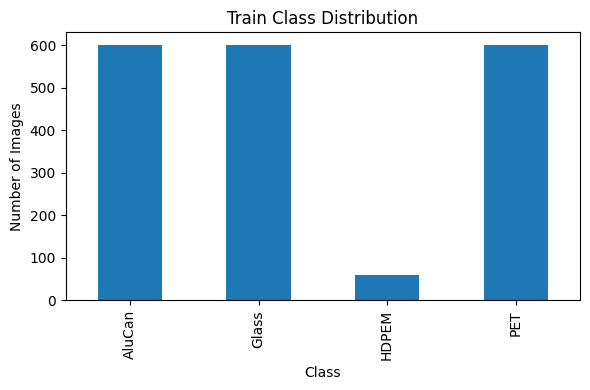


Devtest class counts:
label
AluCan    200
Glass     200
HDPEM      20
PET       200
Name: count, dtype: int64
Imbalance ratio: 10.0:1


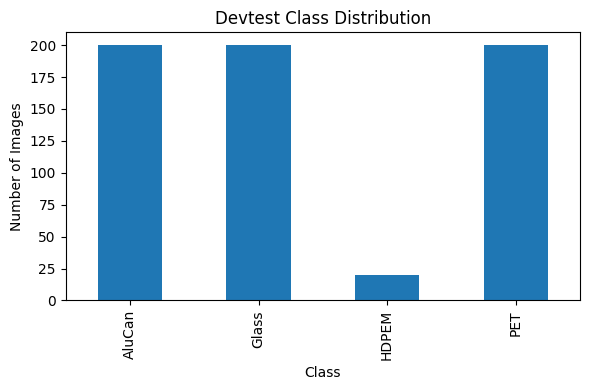


Test class counts:
label
AluCan    200
Glass     200
HDPEM      20
PET       200
Name: count, dtype: int64
Imbalance ratio: 10.0:1


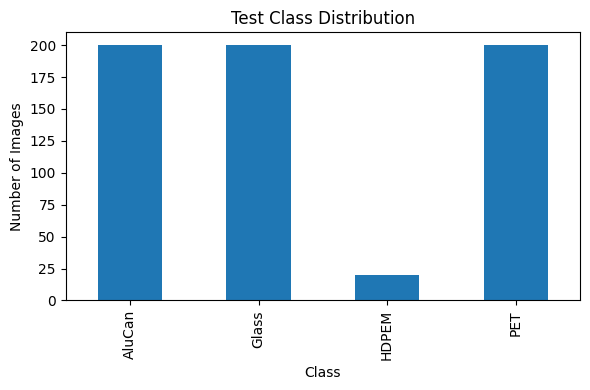

In [3]:
# Display one image from each class in the train, devtest, and test sets

image_root = Path("Images_of_Waste/rawimgs")

classes = ["AluCan", "Glass", "HDPEM", "PET"]

datasets = {
    "Train": train,
    "Devtest": devtest,
    "Test": test
}

fig, axes = plt.subplots(4, 3, figsize=(12, 12))

for row_index, class_name in enumerate(classes):
    for column_index, (dataset_name, dataset_df) in enumerate(datasets.items()):

        # Select one image from the current class
        matching_rows = dataset_df[dataset_df["label"] == class_name]
        selected_row = matching_rows.iloc[0]

        # Create the full image path
        image_path = image_root / selected_row["path"]

        # Read and display the image
        image = plt.imread(image_path)

        axes[row_index, column_index].imshow(image)
        axes[row_index, column_index].axis("off")
        axes[row_index, column_index].set_title(
            f"{class_name} - {dataset_name}"
        )

plt.tight_layout()
plt.show()


# Display the class counts, imbalance ratio, and class distribution
for dataset_name, dataset_df in datasets.items():

    # Count the number of images in each class
    counts = dataset_df["label"].value_counts().reindex(classes)

    # Calculate the imbalance ratio
    imbalance_ratio = counts.max() / counts.min()

    print(f"\n{dataset_name} class counts:")
    print(counts)
    print(f"Imbalance ratio: {imbalance_ratio:.1f}:1")

    # Plot the class distribution
    plt.figure(figsize=(6, 4))

    counts.plot(kind="bar")

    plt.title(f"{dataset_name} Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")

    plt.tight_layout()
    plt.show()

The class distributions across the train, devtest and test sets remained approximately the same, with each dataset having an imbalance ratio of 10:1. HDPEM was the rarest class, with only 60 images in the training set and 20 images in the test set, compared to the other classes which had 600 training images and 200 test images each. Having only 20 HDPEM images in the test set means that the results for this class may be less reliable, as every incorrect prediction will have a larger impact on its overall performance. During training, the model may become more biased towards AluCan, Glass and PET because it has significantly more examples of these classes to learn from. This means that the overall accuracy could still be high even if the model performs poorly when identifying HDPEM images.

Task 2 - Classification

2.1 Custom convolutional neural network

Code Cell 1 - Dataset, transforms and DataLoaders

In [4]:
# Image folder and class information
image_root = Path("Images_of_Waste/rawimgs")

classes = ["AluCan", "Glass", "HDPEM", "PET"]

class_to_index = {
    "AluCan": 0,
    "Glass": 1,
    "HDPEM": 2,
    "PET": 3
}


# Resize images and convert them to PyTorch tensors
IMAGE_SIZE = 128

cnn_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])


# Custom dataset used to load images from the CSV partitions
class WasteDataset(Dataset):

    def __init__(self, dataframe, image_root, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.image_root = Path(image_root)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = self.image_root / row["path"]

        image = Image.open(image_path).convert("RGB")

        label = class_to_index[row["label"]]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# Create the three PyTorch datasets
train_dataset = WasteDataset(
    train,
    image_root,
    transform=cnn_transform
)

devtest_dataset = WasteDataset(
    devtest,
    image_root,
    transform=cnn_transform
)

test_dataset = WasteDataset(
    test,
    image_root,
    transform=cnn_transform
)


# Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

devtest_loader = DataLoader(
    devtest_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


# Check that the dataset and DataLoader have the expected shapes
image, label = train_dataset[0]

print("Single image shape:", image.shape)
print("Single image label:", label)

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Single image shape: torch.Size([3, 128, 128])
Single image label: 1
Batch image shape: torch.Size([32, 3, 128, 128])
Batch label shape: torch.Size([32])


Code Cell 2 - Define CNN

In [5]:
# Custom convolutional neural network
class WasteCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # Feature extraction
        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.MaxPool2d(kernel_size=2),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.MaxPool2d(kernel_size=2),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.MaxPool2d(kernel_size=2),
            nn.ReLU()
        )

        # Classification
        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64 * 16 * 16,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                len(classes)
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


# Display the architecture
example_model = WasteCNN()

print(example_model)

WasteCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


Code Cell 3 - Training and Evaluation Functions

In [6]:
# Train the model for one complete epoch
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients from the previous batch
        optimizer.zero_grad()

        # Make predictions
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Calculate gradients and update the model
        loss.backward()
        optimizer.step()

        # Record loss
        running_loss += loss.item() * images.size(0)

        # Get predicted classes
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy


# Evaluate the model without changing its weights
def evaluate_model(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy

Code Cell 4 - Fresh model, hyperparameters and training

In [7]:
# Create a new CNN so training starts from fresh weights
cnn_model = WasteCNN().to(device)

# Loss function and optimiser
criterion = nn.CrossEntropyLoss()

LEARNING_RATE = 0.0005

cnn_optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=LEARNING_RATE
)

# Early stopping settings
MAX_EPOCHS = 30
PATIENCE = 5

# Reset training history
train_losses = []
devtest_losses = []

train_accuracies = []
devtest_accuracies = []

best_devtest_loss = float("inf")
best_cnn_state = None
epochs_without_improvement = 0
best_epoch = 0


# Train the CNN
for epoch in range(MAX_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        cnn_model,
        train_loader,
        criterion,
        cnn_optimizer
    )

    devtest_loss, devtest_accuracy = evaluate_model(
        cnn_model,
        devtest_loader,
        criterion
    )

    train_losses.append(train_loss)
    devtest_losses.append(devtest_loss)

    train_accuracies.append(train_accuracy)
    devtest_accuracies.append(devtest_accuracy)


    print(
        f"Epoch {epoch + 1}: "
        f"Train loss = {train_loss:.4f}, "
        f"Train accuracy = {train_accuracy:.4f}, "
        f"Devtest loss = {devtest_loss:.4f}, "
        f"Devtest accuracy = {devtest_accuracy:.4f}"
    )


    # Save the model whenever devtest loss improves
    if devtest_loss < best_devtest_loss:

        best_devtest_loss = devtest_loss

        best_cnn_state = copy.deepcopy(
            cnn_model.state_dict()
        )

        best_epoch = epoch + 1
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    # Stop after five epochs without improvement
    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping after epoch {epoch + 1}."
        )

        break


# Restore the model from the best devtest epoch
cnn_model.load_state_dict(best_cnn_state)

print(
    f"\nBest model was from epoch {best_epoch}"
)

print(
    f"Best devtest loss: {best_devtest_loss:.4f}"
)

Epoch 1: Train loss = 1.1988, Train accuracy = 0.3699, Devtest loss = 1.1680, Devtest accuracy = 0.4065
Epoch 2: Train loss = 1.1299, Train accuracy = 0.4930, Devtest loss = 1.0079, Devtest accuracy = 0.6097
Epoch 3: Train loss = 0.8789, Train accuracy = 0.6624, Devtest loss = 0.9887, Devtest accuracy = 0.5661
Epoch 4: Train loss = 0.8129, Train accuracy = 0.6753, Devtest loss = 0.7341, Devtest accuracy = 0.7242
Epoch 5: Train loss = 0.6824, Train accuracy = 0.7306, Devtest loss = 0.6946, Devtest accuracy = 0.7258
Epoch 6: Train loss = 0.6209, Train accuracy = 0.7645, Devtest loss = 0.6663, Devtest accuracy = 0.7435
Epoch 7: Train loss = 0.5486, Train accuracy = 0.7855, Devtest loss = 0.6194, Devtest accuracy = 0.7677
Epoch 8: Train loss = 0.4965, Train accuracy = 0.8113, Devtest loss = 0.6437, Devtest accuracy = 0.7629
Epoch 9: Train loss = 0.4687, Train accuracy = 0.8145, Devtest loss = 0.5755, Devtest accuracy = 0.7839
Epoch 10: Train loss = 0.3994, Train accuracy = 0.8495, Devtest 

Code Cell 5 - Graphs and final test result

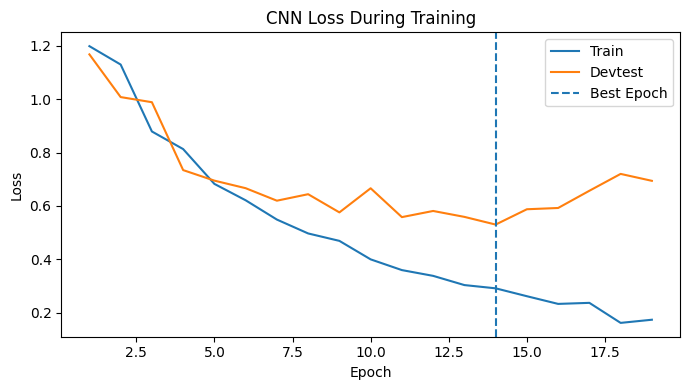

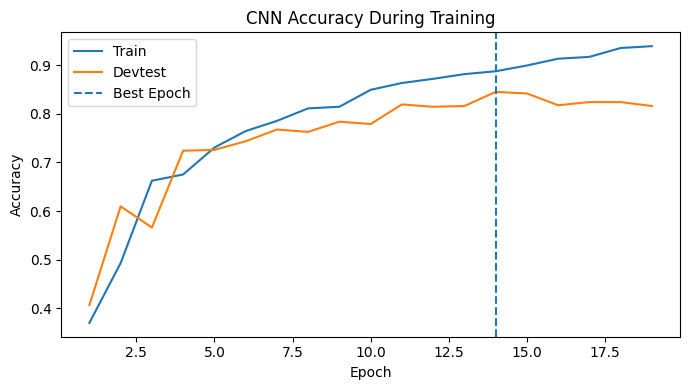

CNN test loss: 0.4913
CNN test accuracy: 0.8355


In [8]:
# Epoch numbers used for plotting
epochs = range(1, len(train_losses) + 1)


# Plot training and devtest loss
plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    train_losses,
    label="Train"
)

plt.plot(
    epochs,
    devtest_losses,
    label="Devtest"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label="Best Epoch"
)

plt.title("CNN Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.tight_layout()
plt.show()


# Plot training and devtest accuracy
plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    train_accuracies,
    label="Train"
)

plt.plot(
    epochs,
    devtest_accuracies,
    label="Devtest"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label="Best Epoch"
)

plt.title("CNN Accuracy During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.tight_layout()
plt.show()


# Final evaluation using the test set
cnn_test_loss, cnn_test_accuracy = evaluate_model(
    cnn_model,
    test_loader,
    criterion
)

print(
    f"CNN test loss: {cnn_test_loss:.4f}"
)

print(
    f"CNN test accuracy: {cnn_test_accuracy:.4f}"
)

Architecture and hyperparameters

The custom CNN was created using three convolutional layers with 16, 32 and 64 filters. Each convolutional layer used a kernel size of 3 and was followed by max pooling with a pool size of 2 and a ReLU activation function. The images were resized to 128 × 128 pixels and a batch size of 32 was used. After the convolutional layers, a fully connected layer with 128 units and dropout of 0.3 was used before the final four-class output layer.

The Adam optimiser and cross-entropy loss were used for training. I tested learning rates of 0.001 and 0.0005. The learning rate of 0.0005 was selected because it produced the lower devtest loss, with 0.5589 compared with 0.6018 when using 0.001.

Early stopping, testing and overfitting

Early stopping was used to determine when training should stop. Training stopped if the devtest loss did not improve for five consecutive epochs. The best model occurred at epoch 14 with a devtest loss of 0.5298 and a devtest accuracy of 84.52%. Training eventually stopped at epoch 19 and the weights from epoch 14 were restored before testing.

After epoch 14, the training accuracy continued to improve while the devtest loss generally increased, indicating that the model had started to overfit the training data. The restored model achieved a final test accuracy of 83.55% with a test loss of 0.4913.

2.2 Pre-trained ResNet18

Code Cell 1 - ResNet transforms and DataLoaders

In [16]:
# Load the default pre-trained ResNet18 weights
resnet_weights = models.ResNet18_Weights.DEFAULT

# Use the preprocessing expected by these pre-trained weights
resnet_transform = resnet_weights.transforms()


# Create datasets using ResNet18 preprocessing
resnet_train_dataset = WasteDataset(
    train,
    image_root,
    transform=resnet_transform
)

resnet_devtest_dataset = WasteDataset(
    devtest,
    image_root,
    transform=resnet_transform
)

resnet_test_dataset = WasteDataset(
    test,
    image_root,
    transform=resnet_transform
)


# Create DataLoaders
resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

resnet_devtest_loader = DataLoader(
    resnet_devtest_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

resnet_test_loader = DataLoader(
    resnet_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# Check the image size
images, labels = next(iter(resnet_train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


Code Cell 2 - Load and freeze ResNet18

In [17]:
# Load ResNet18 pre-trained on ImageNet
resnet_model = models.resnet18(
    weights=resnet_weights
)


# Freeze all pre-trained parameters
for parameter in resnet_model.parameters():
    parameter.requires_grad = False


# Replace the original classification layer
number_of_features = resnet_model.fc.in_features

resnet_model.fc = nn.Linear(
    number_of_features,
    len(classes)
)


# Move model to CPU/GPU
resnet_model = resnet_model.to(device)


# Check which parameters can be trained
for name, parameter in resnet_model.named_parameters():

    if parameter.requires_grad:
        print("Trainable:", name)

Trainable: fc.weight
Trainable: fc.bias


Code Cell 3 - Loss and Optimiser

In [18]:
criterion = nn.CrossEntropyLoss()

RESNET_LEARNING_RATE = 0.001

resnet_optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=RESNET_LEARNING_RATE
)

Code Cell 4 - Train with early stopping

In [19]:
MAX_EPOCHS = 30
PATIENCE = 5


# Store ResNet18 training history
resnet_train_losses = []
resnet_devtest_losses = []

resnet_train_accuracies = []
resnet_devtest_accuracies = []


best_resnet_loss = float("inf")
best_resnet_state = None

resnet_epochs_without_improvement = 0
best_resnet_epoch = 0


for epoch in range(MAX_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        resnet_model,
        resnet_train_loader,
        criterion,
        resnet_optimizer
    )

    devtest_loss, devtest_accuracy = evaluate_model(
        resnet_model,
        resnet_devtest_loader,
        criterion
    )

    resnet_train_losses.append(train_loss)
    resnet_devtest_losses.append(devtest_loss)

    resnet_train_accuracies.append(train_accuracy)
    resnet_devtest_accuracies.append(devtest_accuracy)


    print(
        f"Epoch {epoch + 1}: "
        f"Train loss = {train_loss:.4f}, "
        f"Train accuracy = {train_accuracy:.4f}, "
        f"Devtest loss = {devtest_loss:.4f}, "
        f"Devtest accuracy = {devtest_accuracy:.4f}"
    )


    # Save best model
    if devtest_loss < best_resnet_loss:

        best_resnet_loss = devtest_loss

        best_resnet_state = copy.deepcopy(
            resnet_model.state_dict()
        )

        best_resnet_epoch = epoch + 1
        resnet_epochs_without_improvement = 0

    else:

        resnet_epochs_without_improvement += 1


    # Early stopping
    if resnet_epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping after epoch {epoch + 1}."
        )

        break


# Restore best ResNet18
resnet_model.load_state_dict(
    best_resnet_state
)

print(
    f"\nBest model was from epoch {best_resnet_epoch}"
)

print(
    f"Best devtest loss: {best_resnet_loss:.4f}"
)

Epoch 1: Train loss = 0.9036, Train accuracy = 0.6581, Devtest loss = 0.6005, Devtest accuracy = 0.8065
Epoch 2: Train loss = 0.5399, Train accuracy = 0.8382, Devtest loss = 0.4399, Devtest accuracy = 0.8581
Epoch 3: Train loss = 0.4250, Train accuracy = 0.8688, Devtest loss = 0.3744, Devtest accuracy = 0.8742
Epoch 4: Train loss = 0.3646, Train accuracy = 0.8952, Devtest loss = 0.3214, Devtest accuracy = 0.8968
Epoch 5: Train loss = 0.3411, Train accuracy = 0.8812, Devtest loss = 0.3047, Devtest accuracy = 0.9113
Epoch 6: Train loss = 0.3138, Train accuracy = 0.9027, Devtest loss = 0.2792, Devtest accuracy = 0.9081
Epoch 7: Train loss = 0.3029, Train accuracy = 0.8984, Devtest loss = 0.2784, Devtest accuracy = 0.9097
Epoch 8: Train loss = 0.2672, Train accuracy = 0.9161, Devtest loss = 0.2518, Devtest accuracy = 0.9290
Epoch 9: Train loss = 0.2444, Train accuracy = 0.9247, Devtest loss = 0.2404, Devtest accuracy = 0.9306
Epoch 10: Train loss = 0.2231, Train accuracy = 0.9285, Devtest 

Code Cell 5 - Graphs and final test result

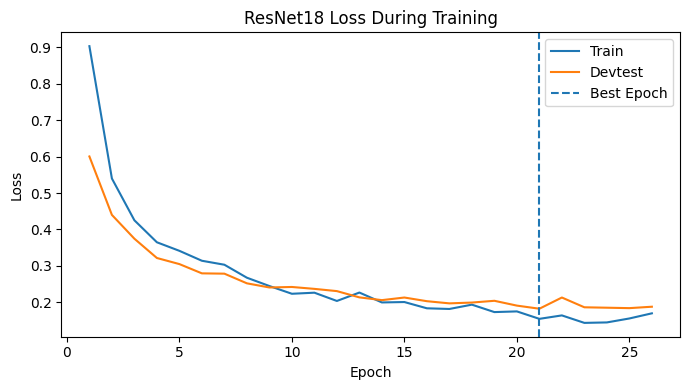

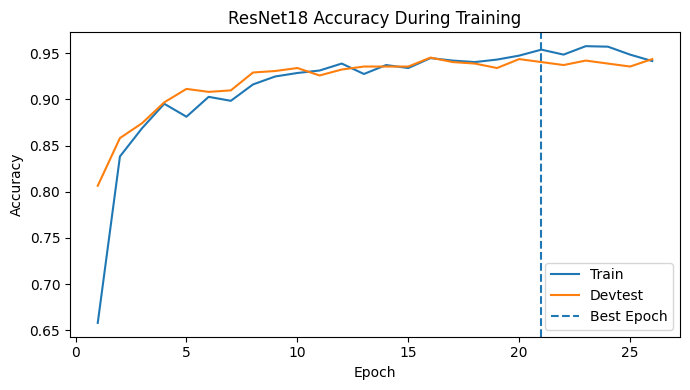

ResNet18 test loss: 0.2166
ResNet18 test accuracy: 0.9306
Custom CNN test accuracy: 0.8355


In [20]:
resnet_epochs = range(
    1,
    len(resnet_train_losses) + 1
)


# Loss graph
plt.figure(figsize=(7, 4))

plt.plot(
    resnet_epochs,
    resnet_train_losses,
    label="Train"
)

plt.plot(
    resnet_epochs,
    resnet_devtest_losses,
    label="Devtest"
)

plt.axvline(
    best_resnet_epoch,
    linestyle="--",
    label="Best Epoch"
)

plt.title("ResNet18 Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# Accuracy graph
plt.figure(figsize=(7, 4))

plt.plot(
    resnet_epochs,
    resnet_train_accuracies,
    label="Train"
)

plt.plot(
    resnet_epochs,
    resnet_devtest_accuracies,
    label="Devtest"
)

plt.axvline(
    best_resnet_epoch,
    linestyle="--",
    label="Best Epoch"
)

plt.title("ResNet18 Accuracy During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# Final test evaluation
resnet_test_loss, resnet_test_accuracy = evaluate_model(
    resnet_model,
    resnet_test_loader,
    criterion
)

print(
    f"ResNet18 test loss: {resnet_test_loss:.4f}"
)

print(
    f"ResNet18 test accuracy: {resnet_test_accuracy:.4f}"
)

print(
    f"Custom CNN test accuracy: {cnn_test_accuracy:.4f}"
)

Model setup and results

For the second system, I used ResNet18 pre-trained on ImageNet. The pre-trained weights were frozen during training so that the existing feature extraction layers would not be changed. The original classification layer was replaced with a new linear layer containing four outputs, one for each waste class. Therefore, only the new final classification layer was trained on the waste dataset.

The ResNet18 model used the preprocessing associated with the pre-trained ImageNet weights and images were processed at 224 × 224 pixels. Early stopping with a patience of five epochs was again used. The best model occurred at epoch 21 with a devtest loss of 0.1820. Training stopped at epoch 26 and the weights from epoch 21 were restored. The final model achieved a test accuracy of 93.06% with a test loss of 0.2166.

Comparison with CNN

ResNet18 performed substantially better than the custom CNN. The custom CNN achieved a test accuracy of 83.55%, while ResNet18 achieved 93.06%, an improvement of approximately 9.51 percentage points.

The ResNet18 training and devtest performance also remained relatively close for most of the training process. Some overfitting began to appear after the best epoch because the training performance remained high while the devtest loss stopped improving consistently. Overall, ResNet18 was the stronger system and was selected as the best Task 2 model.

2.3 Error analysis

Code cell 1 - Get predictions and calculate metrics

In [21]:
# Get the true labels and predictions from a model
def collect_predictions(model, loader):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_predictions)
    )


# Calculate accuracy, macro-F1, recall and test counts
def calculate_metrics(true_labels, predictions):

    accuracy = accuracy_score(
        true_labels,
        predictions
    )

    macro_f1 = f1_score(
        true_labels,
        predictions,
        average="macro"
    )

    recalls = recall_score(
        true_labels,
        predictions,
        labels=range(len(classes)),
        average=None,
        zero_division=0
    )

    counts = np.bincount(
        true_labels,
        minlength=len(classes)
    )

    return accuracy, macro_f1, recalls, counts

Code Cell 2 - Run both models and make the results table

In [22]:
# Get predictions from both models
cnn_true, cnn_predictions = collect_predictions(
    cnn_model,
    test_loader
)

resnet_true, resnet_predictions = collect_predictions(
    resnet_model,
    resnet_test_loader
)


# Calculate metrics
cnn_accuracy, cnn_macro_f1, cnn_recalls, test_counts = (
    calculate_metrics(
        cnn_true,
        cnn_predictions
    )
)

resnet_accuracy, resnet_macro_f1, resnet_recalls, _ = (
    calculate_metrics(
        resnet_true,
        resnet_predictions
    )
)


# Create comparison table
results = []

for class_index, class_name in enumerate(classes):

    results.append({
        "Model": "Custom CNN",
        "Class": class_name,
        "Test Images": test_counts[class_index],
        "Recall": cnn_recalls[class_index],
        "Accuracy": cnn_accuracy,
        "Macro-F1": cnn_macro_f1
    })

    results.append({
        "Model": "ResNet18",
        "Class": class_name,
        "Test Images": test_counts[class_index],
        "Recall": resnet_recalls[class_index],
        "Accuracy": resnet_accuracy,
        "Macro-F1": resnet_macro_f1
    })


results_table = pd.DataFrame(results)

results_table.round(4)

,Model,Class,Test Images,Recall,Accuracy,Macro-F1
0,Custom CNN,AluCan,200,0.820,0.8355,0.7131
1,ResNet18,AluCan,200,0.930,0.9306,0.9158
2,Custom CNN,Glass,200,0.845,0.8355,0.7131
3,ResNet18,Glass,200,0.940,0.9306,0.9158
4,Custom CNN,HDPEM,20,0.250,0.8355,0.7131
5,ResNet18,HDPEM,20,0.800,0.9306,0.9158
6,Custom CNN,PET,200,0.900,0.8355,0.7131
7,ResNet18,PET,200,0.935,0.9306,0.9158


Code Cell 3 - Confusion matrices

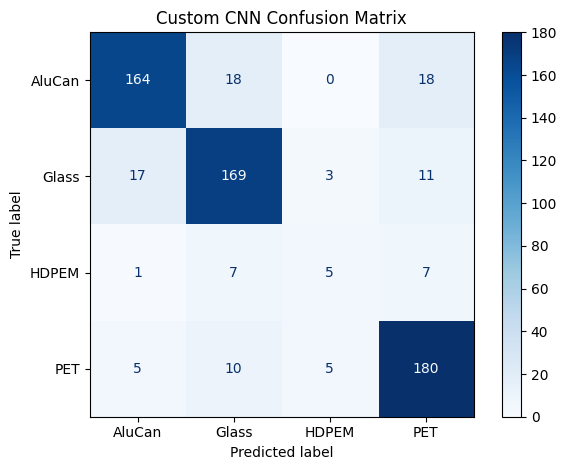

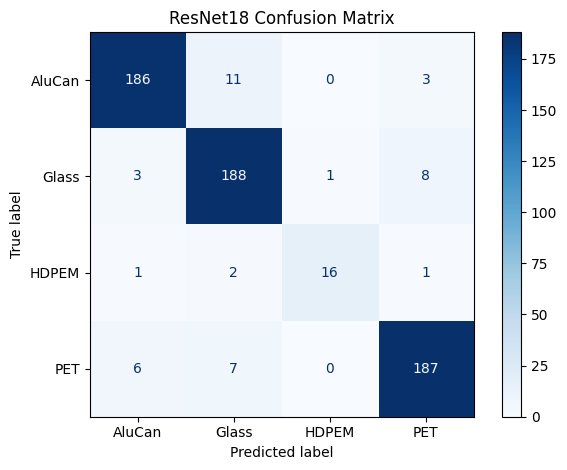

In [23]:
# Custom CNN confusion matrix
ConfusionMatrixDisplay.from_predictions(
    cnn_true,
    cnn_predictions,
    display_labels=classes,
    cmap="Blues"
)

plt.title("Custom CNN Confusion Matrix")
plt.tight_layout()
plt.show()


# ResNet18 confusion matrix
ConfusionMatrixDisplay.from_predictions(
    resnet_true,
    resnet_predictions,
    display_labels=classes,
    cmap="Blues"
)

plt.title("ResNet18 Confusion Matrix")
plt.tight_layout()
plt.show()

Code Cell 4 - Find each model's most common error

In [24]:
# Find the most common incorrect classification
def most_common_error(true_labels, predictions):

    cm = confusion_matrix(
        true_labels,
        predictions,
        labels=range(len(classes))
    )

    # Remove correct predictions
    error_matrix = cm.copy()
    np.fill_diagonal(error_matrix, 0)

    true_class, predicted_class = np.unravel_index(
        np.argmax(error_matrix),
        error_matrix.shape
    )

    error_count = error_matrix[
        true_class,
        predicted_class
    ]

    return true_class, predicted_class, error_count


# CNN
cnn_error_true, cnn_error_pred, cnn_error_count = (
    most_common_error(
        cnn_true,
        cnn_predictions
    )
)

print(
    f"Custom CNN most common error: "
    f"{classes[cnn_error_true]} classified as "
    f"{classes[cnn_error_pred]} "
    f"({cnn_error_count} times)"
)


# ResNet18
resnet_error_true, resnet_error_pred, resnet_error_count = (
    most_common_error(
        resnet_true,
        resnet_predictions
    )
)

print(
    f"ResNet18 most common error: "
    f"{classes[resnet_error_true]} classified as "
    f"{classes[resnet_error_pred]} "
    f"({resnet_error_count} times)"
)

Custom CNN most common error: AluCan classified as Glass (18 times)
ResNet18 most common error: AluCan classified as Glass (11 times)


Code Cell 5 - Display 5 images for the common errors

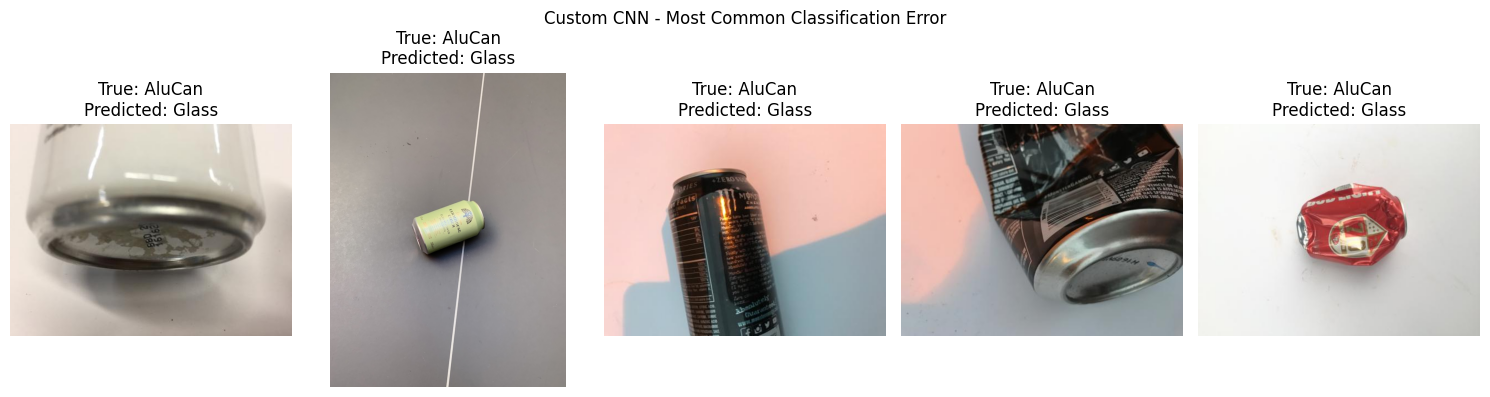

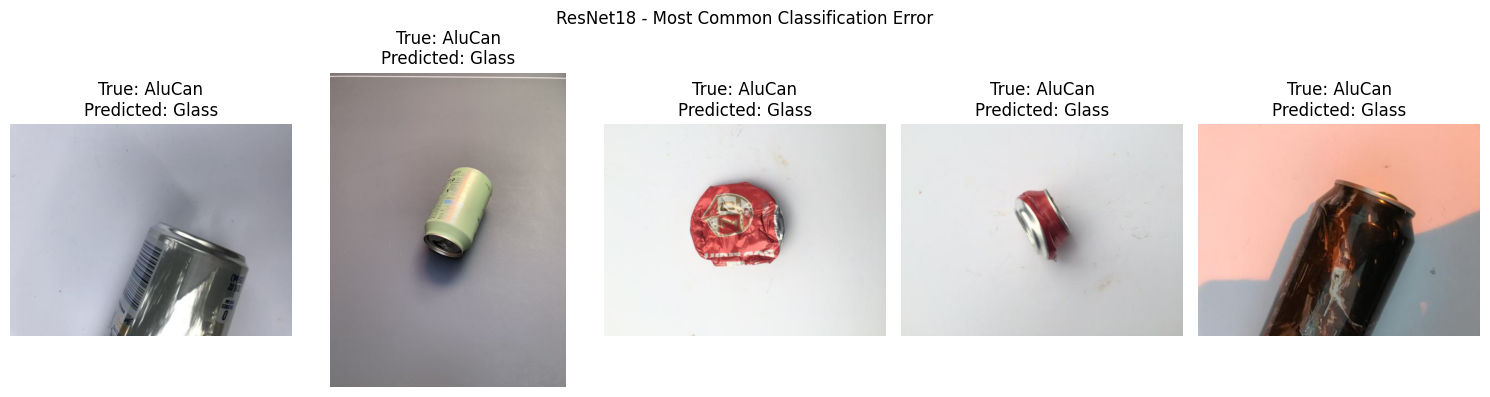

In [25]:
# Reset the test dataframe index so it matches prediction order
test_display = test.reset_index(drop=True)


def display_common_errors(
    true_labels,
    predictions,
    true_class,
    predicted_class,
    model_name
):

    error_indices = np.where(
        (true_labels == true_class) &
        (predictions == predicted_class)
    )[0]

    # Use no more than 5 examples
    error_indices = error_indices[:5]

    number_to_show = len(error_indices)

    if number_to_show == 0:
        print("No examples found.")
        return

    fig, axes = plt.subplots(
        1,
        number_to_show,
        figsize=(3 * number_to_show, 4)
    )

    # Makes axes iterable if only one image exists
    if number_to_show == 1:
        axes = [axes]

    for axis, index in zip(
        axes,
        error_indices
    ):

        row = test_display.iloc[index]

        image_path = (
            image_root / row["path"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        axis.imshow(image)
        axis.axis("off")

        axis.set_title(
            f"True: {classes[true_class]}\n"
            f"Predicted: {classes[predicted_class]}"
        )

    plt.suptitle(
        f"{model_name} - Most Common Classification Error"
    )

    plt.tight_layout()
    plt.show()


# Display CNN errors
display_common_errors(
    cnn_true,
    cnn_predictions,
    cnn_error_true,
    cnn_error_pred,
    "Custom CNN"
)


# Display ResNet18 errors
display_common_errors(
    resnet_true,
    resnet_predictions,
    resnet_error_true,
    resnet_error_pred,
    "ResNet18"
)

Error Analysis - Writing

The Custom CNN achieved an overall accuracy of 83.55% and a macro-F1 score of 71.31%, while ResNet18 achieved an accuracy of 93.06% and a macro-F1 score of 91.58%. ResNet18 therefore performed better overall and produced more consistent results across the four classes.

The Custom CNN achieved recalls of 82.0% for AluCan, 84.5% for Glass, 25.0% for HDPEM and 90.0% for PET. ResNet18 improved these recalls to 93.0%, 94.0%, 80.0% and 93.5% respectively. The largest improvement occurred for HDPEM, where recall increased from 25.0% to 80.0%.

Accuracy vs macro-F1

There was a large difference between accuracy and macro-F1 for the Custom CNN. Its accuracy was 83.55%, while its macro-F1 was 71.31%, giving a difference of approximately 12.24 percentage points. This suggests that the overall accuracy makes the model appear stronger than its performance across all individual classes because the majority classes contribute much more to the total number of correct predictions.

For ResNet18, the accuracy was 93.06% and the macro-F1 score was 91.58%, giving a much smaller difference of approximately 1.48 percentage points. This indicates that ResNet18 performed more consistently across the different classes rather than achieving a high accuracy mainly through the larger classes.

Worst class and how to improve

HDPEM was the worst performing class for both models, although the problem was much more noticeable for the Custom CNN. There were only 60 HDPEM images in the training set compared with 600 images for each of the other classes. This gave the models much less HDPEM data from which to learn useful features.

There were also only 20 HDPEM images in the test set. This means that every individual HDPEM prediction changes the measured recall by 5 percentage points, making its recall less stable than the recall measurements for the other classes, which each contained 200 test images. Increasing the number and variety of real HDPEM training images and applying suitable data augmentation should help improve performance on this class.

Most common classification error

The most common classification error for both models was AluCan being classified as Glass. This occurred 18 times for the Custom CNN and 11 times for ResNet18. Some of the incorrectly classified AluCan images contain unusual viewing angles, crushed cans or reflective surfaces, which may make their visual appearance more difficult to distinguish from Glass.

ResNet18 reduced this error from 18 to 11 cases, which is consistent with its stronger overall performance. The five example images displayed above also show the types of AluCan images that caused this classification error.

Task 3 - Deployment to a webcam

3.1 Generate new HDPEM images

Code Cell 1 - Load and verify the new HDPEM images

In [26]:
# Folder containing the new HDPEM webcam images
webcam_folder = Path("generated_images/HDPEM")

valid_extensions = {
    ".jpg",
    ".jpeg",
    ".png"
}

new_hdpem_images = sorted([
    path
    for path in webcam_folder.iterdir()
    if path.suffix.lower() in valid_extensions
])

print(
    "Number of new HDPEM images:",
    len(new_hdpem_images)
)

if len(new_hdpem_images) < 150:
    raise ValueError(
        "At least 150 new HDPEM images are required."
    )

Number of new HDPEM images: 150


Code Cell 2 - Add the new HDPEM images to the training set

In [27]:
# Prepare the original training data
original_training = train.copy()

original_training["file_path"] = (
    original_training["path"].apply(
        lambda path: str(image_root / path)
    )
)

original_training["source"] = "original"

original_training = original_training[
    [
        "file_path",
        "label",
        "source"
    ]
]


# Create rows for the new webcam images
webcam_training = pd.DataFrame({
    "file_path": [
        str(path)
        for path in new_hdpem_images
    ],
    "label": "HDPEM",
    "source": "webcam"
})


# Add them to the training set only
training_with_webcam = pd.concat(
    [
        original_training,
        webcam_training
    ],
    ignore_index=True
)


print(
    "Original training images:",
    len(original_training)
)

print(
    "New HDPEM webcam images:",
    len(webcam_training)
)

print(
    "Total training images:",
    len(training_with_webcam)
)

Original training images: 1860
New HDPEM webcam images: 150
Total training images: 2010


Code Cell 3 - Report class counts before and after

In [28]:
before_webcam_counts = (
    train["label"]
    .value_counts()
    .reindex(classes)
)

after_webcam_counts = (
    training_with_webcam["label"]
    .value_counts()
    .reindex(classes)
)


print("Before adding webcam images:")
print(before_webcam_counts)

print("\nAfter adding webcam images:")
print(after_webcam_counts)

Before adding webcam images:
label
AluCan    600
Glass     600
HDPEM      60
PET       600
Name: count, dtype: int64

After adding webcam images:
label
AluCan    600
Glass     600
HDPEM     210
PET       600
Name: count, dtype: int64


Code Cell 4 - Plot the training class distributions

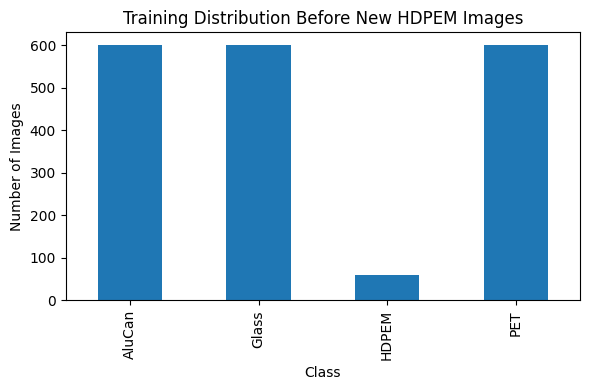

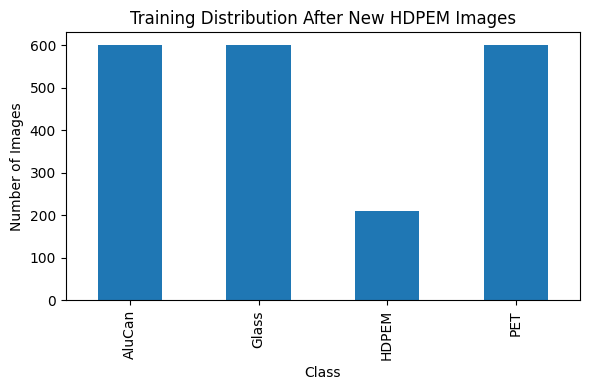

In [29]:
plt.figure(figsize=(6, 4))

before_webcam_counts.plot(
    kind="bar"
)

plt.title(
    "Training Distribution Before New HDPEM Images"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))

after_webcam_counts.plot(
    kind="bar"
)

plt.title(
    "Training Distribution After New HDPEM Images"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

Code Cell 5 - Display examples of the new HDPEM images

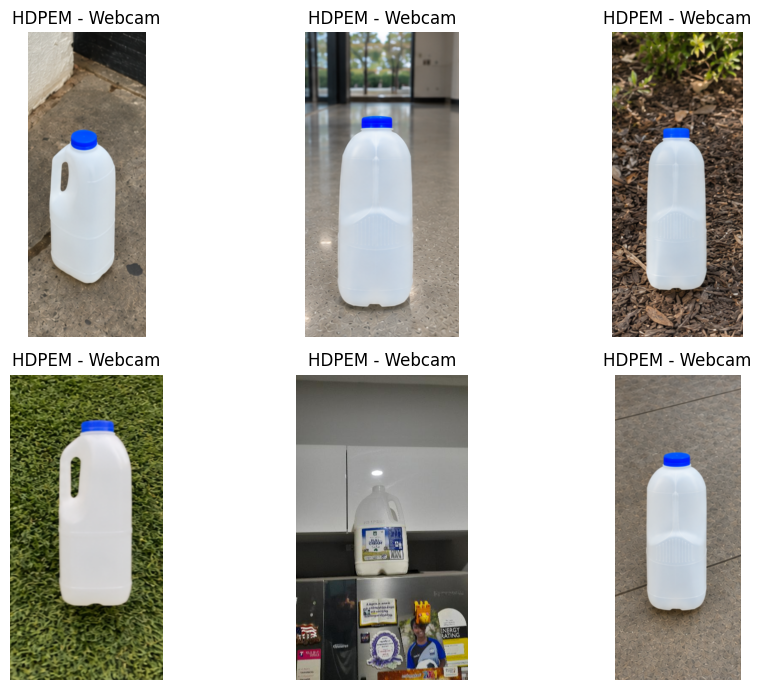

In [30]:
sample_webcam_images = random.sample(
    new_hdpem_images,
    6
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(10, 7)
)

for axis, image_path in zip(
    axes.flatten(),
    sample_webcam_images
):

    image = Image.open(
        image_path
    ).convert("RGB")

    axis.imshow(image)

    axis.set_title(
        "HDPEM - Webcam"
    )

    axis.axis("off")


plt.tight_layout()
plt.show()

### 3.1 Discussion

I captured 150 new images for the HDPEM class using milk bottles and my computer webcam. Milk bottles were chosen because they are HDPE drinking-waste items and match the HDPEM category in the original dataset. While taking the photographs, I changed the position and orientation of the bottle and used different backgrounds and lighting conditions so that the photographs were not near-duplicates.

The new photographs were stored in the generated_images/HDPEM folder. Only the new HDPEM photographs were placed in this folder. The code searches the folder for JPG, JPEG and PNG files, stores their paths, and assigns each of them the HDPEM label. These image paths are then added to the existing training data only. The devtest and test DataFrames are not changed, which ensures that Task 3 is evaluated using exactly the same test images as Task 2. Someone reproducing this process could place their HDPEM photographs in the same folder structure and run the loading and concatenation cells.

Before adding the new photographs, the training set contained 600 AluCan images, 600 Glass images, 60 HDPEM images and 600 PET images. Adding the 150 new photographs increased HDPEM from 60 to 210 training images. The other three classes remained unchanged at 600 images each. Although this reduced the imbalance, HDPEM was still considerably smaller than the other classes, so further balancing was required in Section 3.2.

3.2 Balance the training data using augmentation

Code Cell 1 - Define augmentation and balance the metadata

In [31]:
# Augmentation applied only to additional HDPEM training samples
hdpem_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    # Apply the same preprocessing used by ResNet18 in Task 2
    resnet_transform
])


# Count classes before augmentation
before_augmentation_counts = (
    training_with_webcam["label"]
    .value_counts()
    .reindex(classes)
)

print("Before augmentation:")
print(before_augmentation_counts)


# Use the largest class as the target size
target_count = before_augmentation_counts.max()

hdpem_count = before_augmentation_counts["HDPEM"]

images_needed = target_count - hdpem_count

print(
    "\nAdditional augmented HDPEM samples needed:",
    images_needed
)


# Mark the existing real images as non-augmented
balanced_training = training_with_webcam.copy()

balanced_training["augment"] = False


# Select all real HDPEM training images
hdpem_rows = balanced_training[
    balanced_training["label"] == "HDPEM"
]


# Sample HDPEM images again to create
# additional augmented training examples
augmented_rows = hdpem_rows.sample(
    n=images_needed,
    replace=True,
    random_state=42
).copy()

augmented_rows["augment"] = True
augmented_rows["source"] = "augmentation"


# Add the augmented entries to the training set
balanced_training = pd.concat(
    [
        balanced_training,
        augmented_rows
    ],
    ignore_index=True
)


# Count classes after augmentation
after_augmentation_counts = (
    balanced_training["label"]
    .value_counts()
    .reindex(classes)
)

print("\nAfter augmentation:")
print(after_augmentation_counts)

Before augmentation:
label
AluCan    600
Glass     600
HDPEM     210
PET       600
Name: count, dtype: int64

Additional augmented HDPEM samples needed: 390

After augmentation:
label
AluCan    600
Glass     600
HDPEM     600
PET       600
Name: count, dtype: int64


Code Cell 2 - Plot class distribution before and after augmentation

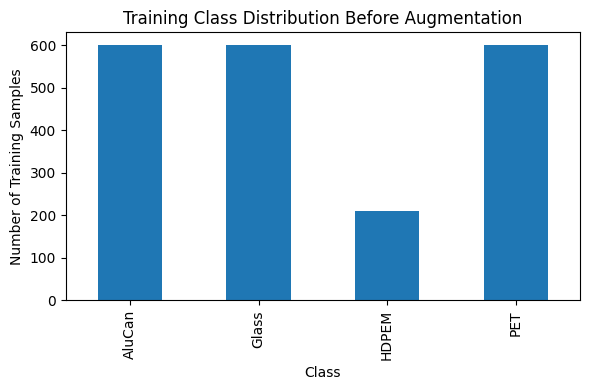

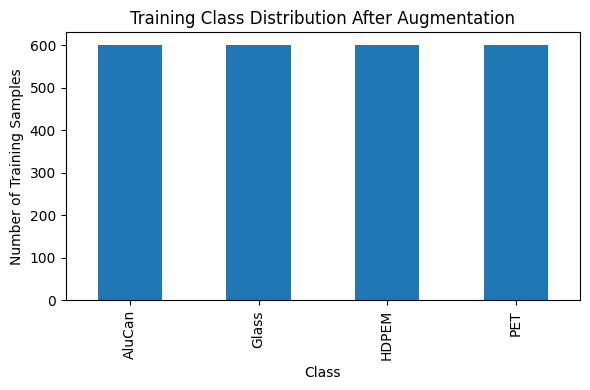

In [32]:
# Distribution before augmentation
plt.figure(figsize=(6, 4))

before_augmentation_counts.plot(
    kind="bar"
)

plt.title(
    "Training Class Distribution Before Augmentation"
)

plt.xlabel("Class")
plt.ylabel("Number of Training Samples")

plt.tight_layout()
plt.show()


# Distribution after augmentation
plt.figure(figsize=(6, 4))

after_augmentation_counts.plot(
    kind="bar"
)

plt.title(
    "Training Class Distribution After Augmentation"
)

plt.xlabel("Class")
plt.ylabel("Number of Training Samples")

plt.tight_layout()
plt.show()

Code Cell 3 - Display one original HDPEM image and four augmented versions

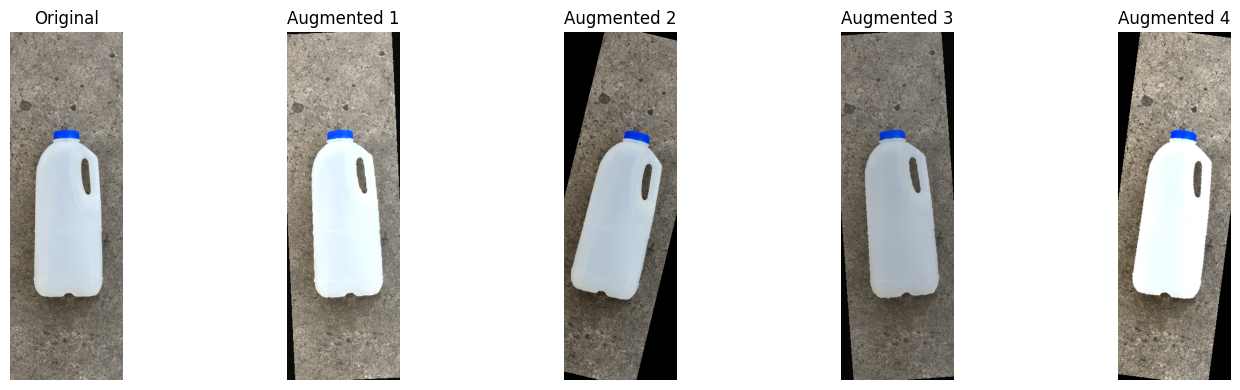

In [33]:
# Transform used only for displaying augmentation examples
augmentation_preview = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    )
])


# Select one of the new real HDPEM images
original_image = Image.open(
    new_hdpem_images[0]
).convert("RGB")


fig, axes = plt.subplots(
    1,
    5,
    figsize=(15, 4)
)


# Original image
axes[0].imshow(original_image)
axes[0].set_title("Original")
axes[0].axis("off")


# Four randomly augmented versions
for index in range(1, 5):

    augmented_image = augmentation_preview(
        original_image
    )

    axes[index].imshow(
        augmented_image
    )

    axes[index].set_title(
        f"Augmented {index}"
    )

    axes[index].axis("off")


plt.tight_layout()
plt.show()

Code Cell 4 - Create balanced training dataset

In [34]:
class BalancedWasteDataset(Dataset):

    def __init__(
        self,
        dataframe,
        normal_transform,
        augmentation_transform
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.normal_transform = normal_transform
        self.augmentation_transform = augmentation_transform


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(
            row["file_path"]
        ).convert("RGB")

        label = class_to_index[
            row["label"]
        ]


        # Apply augmentation only to the artificial HDPEM rows
        if row["augment"]:

            image = self.augmentation_transform(
                image
            )

        else:

            image = self.normal_transform(
                image
            )


        return image, label

Code Cell 5 - Create balanced training DataLoader

In [35]:
balanced_train_dataset = BalancedWasteDataset(
    balanced_training,
    normal_transform=resnet_transform,
    augmentation_transform=hdpem_augmentation
)


balanced_train_loader = DataLoader(
    balanced_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)


# Check that the loader works
images, labels = next(
    iter(balanced_train_loader)
)


print(
    "Balanced batch shape:",
    images.shape
)

print(
    "Balanced training samples:",
    len(balanced_train_dataset)
)

Balanced batch shape: torch.Size([32, 3, 224, 224])
Balanced training samples: 2400


### 3.2 Discussion

The HDPEM training class contained 210 real images after Section 3.1, compared with 600 images for each of the other classes. I therefore created 390 additional HDPEM training samples using data augmentation, giving all four classes 600 training samples and a total balanced training set of 2400 samples.

I used random horizontal flipping, rotations of up to 15 degrees, and small brightness and contrast changes. Horizontal flipping provides different orientations of the object, rotation represents small differences in camera or bottle angle, and brightness and contrast changes represent differences in lighting. These transformations are relatively small, so they add useful variation without changing the image enough that the milk bottle should belong to a different class.

Augmentation was applied only to HDPEM examples in the training set. The devtest and test sets were left as real, unmodified photographs because they are intended to measure performance on unseen data. If the evaluation images were also augmented, the evaluation conditions would change and the comparison against the Task 2 model would no longer be fair or consistent.

3.3 Fine-tune and evaluate the best model

Code Cell 1 - Preserve the original ResNet and create fine-tuning copy

In [36]:
# Keep an unchanged copy of the Task 2 ResNet18
resnet_before_finetuning = copy.deepcopy(
    resnet_model
).to(device)


# Create a copy to train on the balanced dataset
resnet_finetuned = copy.deepcopy(
    resnet_model
).to(device)


# Keep the pre-trained backbone frozen
for parameter in resnet_finetuned.parameters():
    parameter.requires_grad = False


# Allow the final classification layer to train
for parameter in resnet_finetuned.fc.parameters():
    parameter.requires_grad = True


print("Trainable parameters:")

for name, parameter in resnet_finetuned.named_parameters():

    if parameter.requires_grad:
        print(name)

Trainable parameters:
fc.weight
fc.bias


Code Cell 2 - Fine tune on balanced training data

In [37]:
fine_tune_criterion = nn.CrossEntropyLoss()

FINE_TUNE_LEARNING_RATE = 0.0005

fine_tune_optimizer = optim.Adam(
    resnet_finetuned.fc.parameters(),
    lr=FINE_TUNE_LEARNING_RATE
)


MAX_FINE_TUNE_EPOCHS = 20
FINE_TUNE_PATIENCE = 5


fine_tune_train_losses = []
fine_tune_devtest_losses = []

fine_tune_train_accuracies = []
fine_tune_devtest_accuracies = []


best_fine_tune_loss = float("inf")
best_fine_tune_state = None

best_fine_tune_epoch = 0
fine_tune_epochs_without_improvement = 0


for epoch in range(MAX_FINE_TUNE_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        resnet_finetuned,
        balanced_train_loader,
        fine_tune_criterion,
        fine_tune_optimizer
    )


    devtest_loss, devtest_accuracy = evaluate_model(
        resnet_finetuned,
        resnet_devtest_loader,
        fine_tune_criterion
    )


    fine_tune_train_losses.append(
        train_loss
    )

    fine_tune_devtest_losses.append(
        devtest_loss
    )

    fine_tune_train_accuracies.append(
        train_accuracy
    )

    fine_tune_devtest_accuracies.append(
        devtest_accuracy
    )


    print(
        f"Epoch {epoch + 1}: "
        f"Train loss = {train_loss:.4f}, "
        f"Train accuracy = {train_accuracy:.4f}, "
        f"Devtest loss = {devtest_loss:.4f}, "
        f"Devtest accuracy = {devtest_accuracy:.4f}"
    )


    if devtest_loss < best_fine_tune_loss:

        best_fine_tune_loss = devtest_loss

        best_fine_tune_state = copy.deepcopy(
            resnet_finetuned.state_dict()
        )

        best_fine_tune_epoch = epoch + 1

        fine_tune_epochs_without_improvement = 0

    else:

        fine_tune_epochs_without_improvement += 1


    if (
        fine_tune_epochs_without_improvement
        >= FINE_TUNE_PATIENCE
    ):

        print(
            f"\nEarly stopping after epoch "
            f"{epoch + 1}."
        )

        break


# Restore the best fine-tuned model
resnet_finetuned.load_state_dict(
    best_fine_tune_state
)


print(
    f"\nBest model was from epoch "
    f"{best_fine_tune_epoch}"
)

print(
    f"Best devtest loss: "
    f"{best_fine_tune_loss:.4f}"
)

Epoch 1: Train loss = 0.1773, Train accuracy = 0.9446, Devtest loss = 0.2032, Devtest accuracy = 0.9403
Epoch 2: Train loss = 0.1491, Train accuracy = 0.9546, Devtest loss = 0.1909, Devtest accuracy = 0.9435
Epoch 3: Train loss = 0.1416, Train accuracy = 0.9571, Devtest loss = 0.1884, Devtest accuracy = 0.9468
Epoch 4: Train loss = 0.1435, Train accuracy = 0.9575, Devtest loss = 0.1821, Devtest accuracy = 0.9500
Epoch 5: Train loss = 0.1323, Train accuracy = 0.9629, Devtest loss = 0.1804, Devtest accuracy = 0.9468
Epoch 6: Train loss = 0.1350, Train accuracy = 0.9558, Devtest loss = 0.1678, Devtest accuracy = 0.9500
Epoch 7: Train loss = 0.1144, Train accuracy = 0.9692, Devtest loss = 0.1787, Devtest accuracy = 0.9516
Epoch 8: Train loss = 0.1258, Train accuracy = 0.9600, Devtest loss = 0.1645, Devtest accuracy = 0.9516
Epoch 9: Train loss = 0.1130, Train accuracy = 0.9704, Devtest loss = 0.1649, Devtest accuracy = 0.9484
Epoch 10: Train loss = 0.1129, Train accuracy = 0.9671, Devtest 

Code Cell 3 - Calculate metrics before and after fine-tuning

In [39]:
# Predictions before fine-tuning
before_true, before_predictions = (
    collect_predictions(
        resnet_before_finetuning,
        resnet_test_loader
    )
)


# Predictions after fine-tuning
after_true, after_predictions = (
    collect_predictions(
        resnet_finetuned,
        resnet_test_loader
    )
)


# Metrics before fine-tuning
(
    before_accuracy,
    before_macro_f1,
    before_recalls,
    test_counts
) = calculate_metrics(
    before_true,
    before_predictions
)


# Metrics after fine-tuning
(
    after_accuracy,
    after_macro_f1,
    after_recalls,
    _
) = calculate_metrics(
    after_true,
    after_predictions
)


# Create a clear before/after table
fine_tuning_table = pd.DataFrame({
    "Stage": [
        "Before Fine-tuning",
        "After Fine-tuning"
    ],

    "Accuracy": [
        before_accuracy,
        after_accuracy
    ],

    "Macro-F1": [
        before_macro_f1,
        after_macro_f1
    ],

    "AluCan Recall": [
        before_recalls[0],
        after_recalls[0]
    ],

    "Glass Recall": [
        before_recalls[1],
        after_recalls[1]
    ],

    "HDPEM Recall": [
        before_recalls[2],
        after_recalls[2]
    ],

    "PET Recall": [
        before_recalls[3],
        after_recalls[3]
    ]
})


fine_tuning_table.round(4)

,Stage,Accuracy,Macro-F1,AluCan Recall,Glass Recall,HDPEM Recall,PET Recall
0,Before Fine-tuning,0.9306,0.9158,0.93,0.940,0.8,0.935
1,After Fine-tuning,0.9371,0.9288,0.93,0.935,0.9,0.950


Code Cell 4 - Confusion matrices before and after

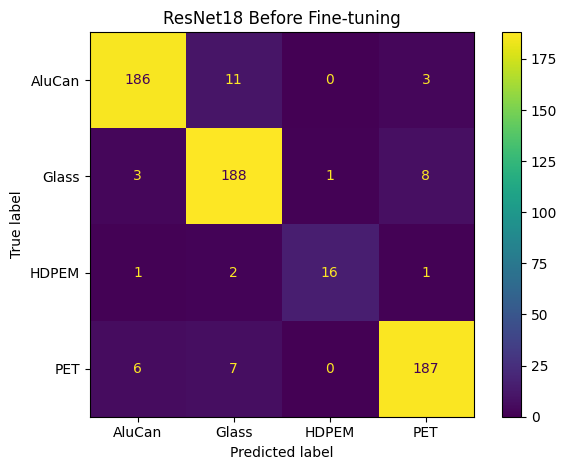

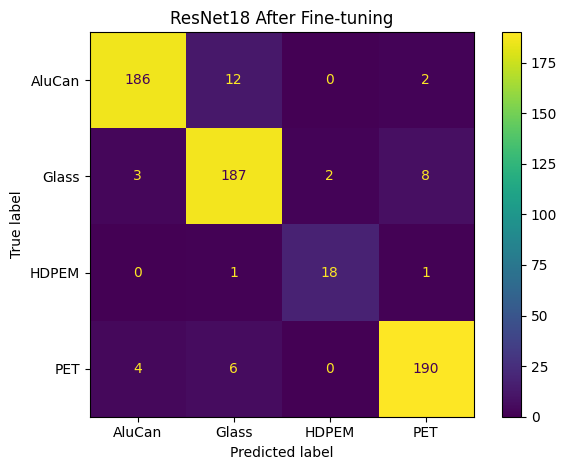

In [40]:
before_matrix = confusion_matrix(
    before_true,
    before_predictions
)

after_matrix = confusion_matrix(
    after_true,
    after_predictions
)


# Before fine-tuning
before_display = ConfusionMatrixDisplay(
    confusion_matrix=before_matrix,
    display_labels=classes
)

before_display.plot()

plt.title(
    "ResNet18 Before Fine-tuning"
)

plt.tight_layout()
plt.show()


# After fine-tuning
after_display = ConfusionMatrixDisplay(
    confusion_matrix=after_matrix,
    display_labels=classes
)

after_display.plot()

plt.title(
    "ResNet18 After Fine-tuning"
)

plt.tight_layout()
plt.show()

Code Cell 5 - Compare classifications errors before and after

In [41]:
error_changes = []


for true_index, true_class in enumerate(classes):

    for predicted_index, predicted_class in enumerate(classes):

        # Skip correct classifications
        if true_index == predicted_index:
            continue


        before_errors = before_matrix[
            true_index,
            predicted_index
        ]

        after_errors = after_matrix[
            true_index,
            predicted_index
        ]


        error_changes.append({
            "True Class": true_class,
            "Predicted As": predicted_class,
            "Before": before_errors,
            "After": after_errors,
            "Change": after_errors - before_errors
        })


error_change_table = pd.DataFrame(
    error_changes
)


error_change_table.sort_values(
    "Change"
)

,True Class,Predicted As,Before,After,Change
9,PET,AluCan,6,4,-2
2,AluCan,PET,3,2,-1
6,HDPEM,AluCan,1,0,-1
7,HDPEM,Glass,2,1,-1
10,PET,Glass,7,6,-1
3,Glass,AluCan,3,3,0
5,Glass,PET,8,8,0
1,AluCan,HDPEM,0,0,0
8,HDPEM,PET,1,1,0
11,PET,HDPEM,0,0,0


Code Cell 6 - Print main metric changes

In [42]:
print(
    f"Accuracy: "
    f"{before_accuracy:.4f} -> "
    f"{after_accuracy:.4f}"
)

print(
    f"Macro-F1: "
    f"{before_macro_f1:.4f} -> "
    f"{after_macro_f1:.4f}"
)


print("\nPer-class recall changes:")

for index, class_name in enumerate(classes):

    print(
        f"{class_name}: "
        f"{before_recalls[index]:.4f} -> "
        f"{after_recalls[index]:.4f}"
    )

Accuracy: 0.9306 -> 0.9371
Macro-F1: 0.9158 -> 0.9288

Per-class recall changes:
AluCan: 0.9300 -> 0.9300
Glass: 0.9400 -> 0.9350
HDPEM: 0.8000 -> 0.9000
PET: 0.9350 -> 0.9500


### 3.3 Discussion

Fine-tuning on the balanced training set produced the largest improvement for HDPEM. Its recall increased from 80% to 90%, an improvement of 10 percentage points. Because the HDPEM test set contains 20 images, this corresponds to an increase from 16 correctly recognised HDPEM images to 18 out of 20. AluCan recall stayed unchanged at 93%, Glass decreased slightly from 94% to 93.5%, and PET improved from 93.5% to 95%. Therefore, the additional HDPEM images and balancing improved the minority class substantially without causing a large reduction in the performance of the other classes.

Accuracy:
93.71% - 93.06% = +0.65 percentage points

Macro-F1:
92.88% - 91.58% = +1.30 percentage points

Macro-F1 improved more than overall accuracy. Accuracy increased by approximately 0.65 percentage points, while macro-F1 increased by approximately 1.30 percentage points. This occurred because the main improvement was in HDPEM, which is the minority class. Overall accuracy is dominated more heavily by AluCan, Glass and PET because they each have 200 test images, whereas HDPEM has only 20. Macro-F1 gives each class equal importance, so the large improvement in HDPEM recall has a greater effect on macro-F1 than on overall accuracy.

The confusion matrices show that several classification errors became less common after fine-tuning. PET being classified as AluCan decreased from 6 to 4 cases. AluCan being classified as PET decreased from 3 to 2, HDPEM being classified as AluCan decreased from 1 to 0, HDPEM being classified as Glass decreased from 2 to 1, and PET being classified as Glass decreased from 7 to 6. The reductions in HDPEM errors are consistent with its recall increasing from 80% to 90%.
A small number of errors became more common. Glass being classified as HDPEM increased from 1 to 2 cases, while AluCan being classified as Glass increased from 11 to 12. Other error types remained unchanged. This shows that balancing the training set mainly improved HDPEM recognition, although there were small trade-offs for some classifications involving the other classes.